# Gain scheduling - PID

This script derives optimal PID gains ($K_p$, $K_i$, $K_d$) mathematically by matching the closed-loop characteristic polynomial with desired poles.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# Identified parameters from phys_14_drone.ipynb
c1 = -8.29151533
c2 = 0.00418887
c3 = -1.43673669

# Bounds
u_min, u_max = -100.0, 100.0
Ts = 0.05  # Sampling time


## 1. Linearization and Analytical PID Derivation

The continuous-time dynamics of the drone, using the virtual control $v = u|u|$, is given by:
$$ \ddot{\theta} = c_1 \sin(\theta) + c_3 \dot{\theta} + c_2 v $$

To linearize the system around an equilibrium angle $\theta_{eq}$ (where $\dot{\theta} = 0$ and $\ddot{\theta} = 0$), we find the equilibrium virtual control $v_{eq}$:
$$ 0 = c_1 \sin(\theta_{eq}) + c_2 v_{eq} \implies v_{eq} = -\frac{c_1}{c_2}\sin(\theta_{eq}) $$

Introducing small perturbations $\theta = \theta_{eq} + \tilde{\theta}$ and $v = v_{eq} + \tilde{v}$, and substituting into the dynamics:
$$ \ddot{\tilde{\theta}} = c_1 \sin(\theta_{eq} + \tilde{\theta}) + c_3 \dot{\tilde{\theta}} + c_2 (v_{eq} + \tilde{v}) $$

Using the first-order Taylor expansion $\sin(\theta_{eq} + \tilde{\theta}) \approx \sin(\theta_{eq}) + \cos(\theta_{eq})\tilde{\theta}$:
$$ \ddot{\tilde{\theta}} \approx c_1 \sin(\theta_{eq}) + c_1 \cos(\theta_{eq})\tilde{\theta} + c_3 \dot{\tilde{\theta}} + c_2 v_{eq} + c_2 \tilde{v} $$

Since $c_1 \sin(\theta_{eq}) + c_2 v_{eq} = 0$, those terms cancel out. Taking the Laplace transform of the resulting linearized plant yields the open-loop transfer function:
$$ G_p(s) = \frac{\Theta(s)}{V(s)} = \frac{c_2}{s^2 - c_3 s - c_1 \cos(\theta_{eq})} $$

A standard PID controller in the Laplace domain is:
$$ C(s) = K_p + \frac{K_i}{s} + K_d s = \frac{K_d s^2 + K_p s + K_i}{s} $$

In a unity-feedback loop, the closed-loop transfer function $T(s)$ from reference $R(s)$ to output $\Theta(s)$ is:
$$ T(s) = \frac{C(s)G_p(s)}{1 + C(s)G_p(s)} = \frac{c_2 (K_d s^2 + K_p s + K_i)}{s(s^2 - c_3 s - c_1 \cos(\theta_{eq})) + c_2(K_d s^2 + K_p s + K_i)} $$

The denominator is the **Closed-Loop Characteristic Polynomial**:
$$ s^3 + (c_2 K_d - c_3)s^2 + (c_2 K_p - c_1 \cos(\theta_{eq}))s + c_2 K_i = 0 $$

If we desire closed-loop poles at $p_1, p_2, p_3$, our desired characteristic polynomial is:
$$ (s - p_1)(s - p_2)(s - p_3) = s^3 + \alpha_2 s^2 + \alpha_1 s + \alpha_0 = 0 $$

Equating coefficients, we obtain the exact analytical gains:
1. $K_d = \frac{\alpha_2 + c_3}{c_2}$
2. $K_p(\theta_{eq}) = \frac{\alpha_1 + c_1 \cos(\theta_{eq})}{c_2}$
3. $K_i = \frac{\alpha_0}{c_2}$


In [32]:
angles_deg = np.array([0, 30, 60, 90, 120, 150, 180], dtype=float)
angles_rad = np.deg2rad(angles_deg)

v_eq_list = []
Kp_list, Ki_list, Kd_list = [], [], []

# Desired poles for the closed-loop system
P_desired = [-2, -2.5, -3]
alpha = np.poly(P_desired)  # Result: [1, alpha2, alpha1, alpha0]
alpha2, alpha1, alpha0 = alpha[1], alpha[2], alpha[3]

print("Analytical PID Design Summary:")
print("-" * 60)
for th in angles_rad:
    sin_th = np.clip(np.sin(th), 0, None) 
    cos_th = np.cos(th)
    
    # Equilibrium virtual control
    v_eq = (-c1 * sin_th) / c2
    v_eq_list.append(v_eq)
    
    # Analytical PID matching from pole placement:
    # s^3 + (c2*Kd - c3)s^2 + (c2*Kp - c1*cos(th))s + c2*Ki = 0
    
    Kd_opt = (alpha2 + c3) / c2
    Kp_opt = (alpha1 + c1 * cos_th) / c2
    Ki_opt = alpha0 / c2
    
    Kp_list.append(Kp_opt)
    Ki_list.append(Ki_opt)
    Kd_list.append(Kd_opt)
    
    print(f"Angle {np.rad2deg(th):>3.0f} deg | Kp={Kp_opt:.1f}, Ki={Ki_opt:.1f}, Kd={Kd_opt:.1f}")


Analytical PID Design Summary:
------------------------------------------------------------
Angle   0 deg | Kp=2437.0, Ki=3580.9, Kd=1447.5
Angle  30 deg | Kp=2702.2, Ki=3580.9, Kd=1447.5
Angle  60 deg | Kp=3426.8, Ki=3580.9, Kd=1447.5
Angle  90 deg | Kp=4416.5, Ki=3580.9, Kd=1447.5
Angle 120 deg | Kp=5406.2, Ki=3580.9, Kd=1447.5
Angle 150 deg | Kp=6130.7, Ki=3580.9, Kd=1447.5
Angle 180 deg | Kp=6395.9, Ki=3580.9, Kd=1447.5


## 2. PID Gain Scheduling Interpolators

In [33]:
interp_veq = interp1d(angles_deg, v_eq_list, kind='cubic', fill_value='extrapolate')
interp_Kp = interp1d(angles_deg, Kp_list, kind='linear', fill_value='extrapolate')
interp_Ki = interp1d(angles_deg, Ki_list, kind='linear', fill_value='extrapolate')
interp_Kd = interp1d(angles_deg, Kd_list, kind='linear', fill_value='extrapolate')

print("Interpolators created.")


Interpolators created.


## 3. Visualization of Scheduled PID Gains

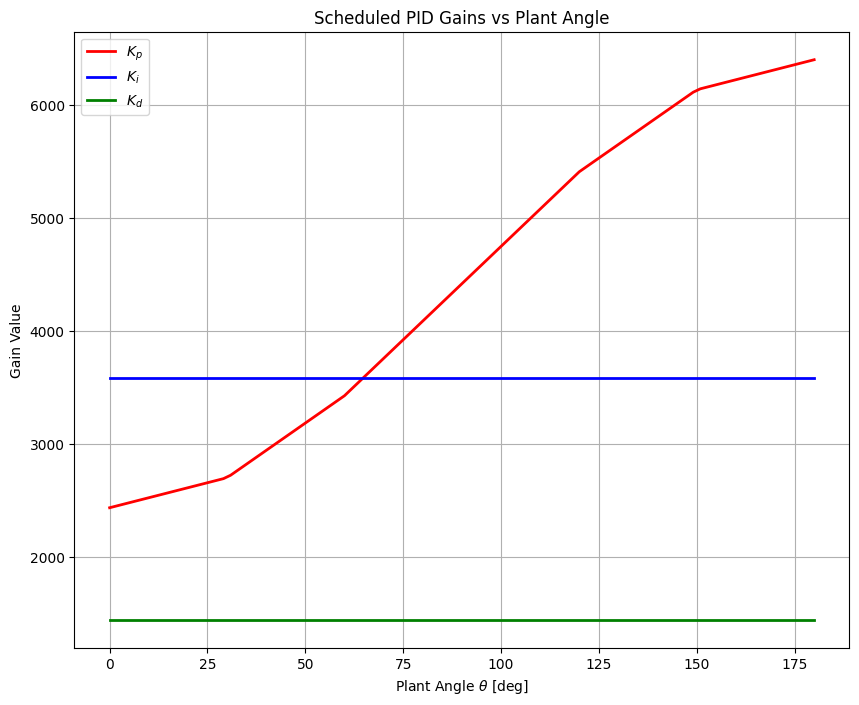

In [34]:
th_plot = np.linspace(0, 180, 100)

Kp_plot = interp_Kp(th_plot)
Ki_plot = interp_Ki(th_plot)
Kd_plot = interp_Kd(th_plot)

plt.figure(figsize=(10, 8))
plt.plot(th_plot, Kp_plot, 'r-', lw=2, label='$K_p$')
plt.plot(th_plot, Ki_plot, 'b-', lw=2, label='$K_i$')
plt.plot(th_plot, Kd_plot, 'g-', lw=2, label='$K_d$')
plt.title('Scheduled PID Gains vs Plant Angle')
plt.xlabel('Plant Angle $\\theta$ [deg]')
plt.ylabel('Gain Value')
plt.legend()
plt.grid(True)
plt.show()


## 4. Nonlinear Simulation
We simulate the staircase reference using the difference equation computing virtual control $\Delta v[k]$.

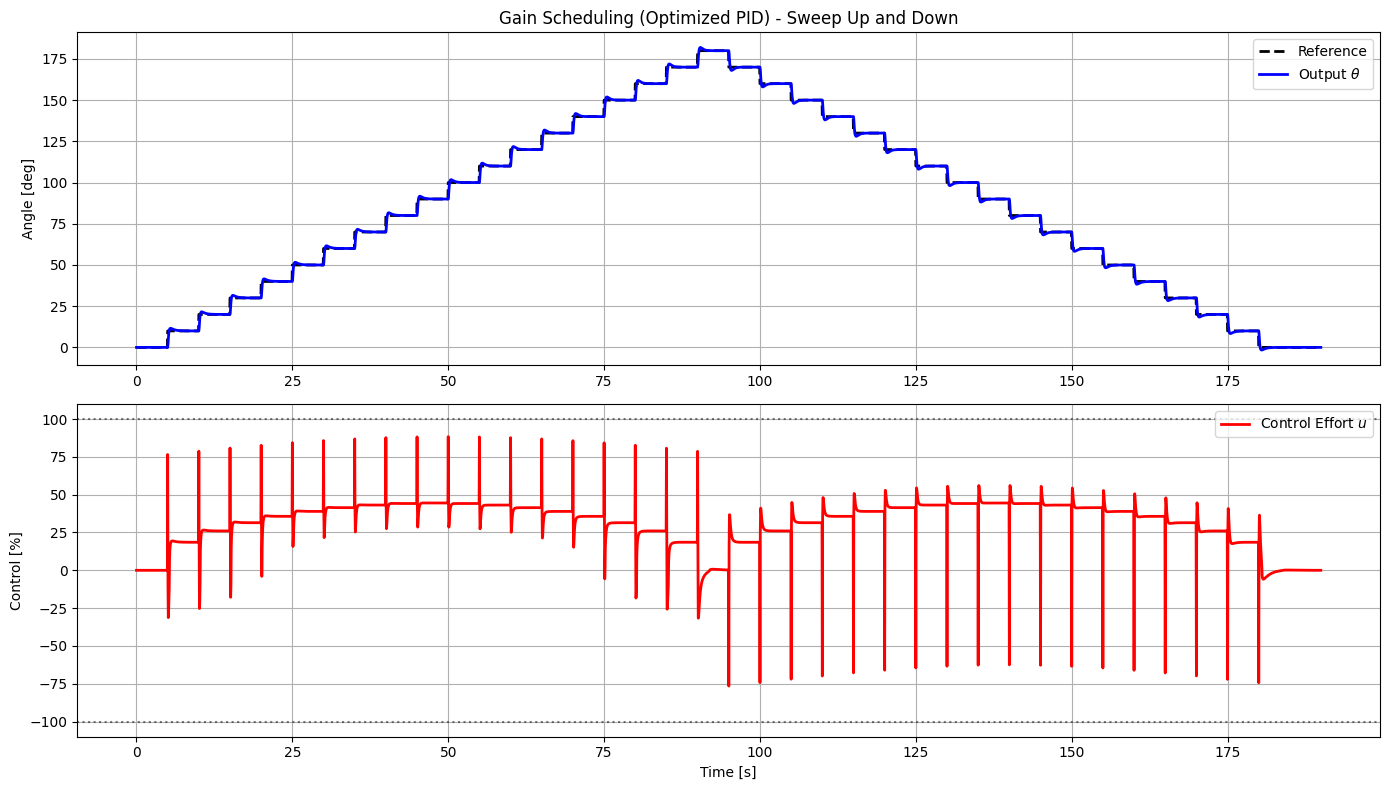

In [35]:
# Simulation Settings
T_sim = 190.0
t_steps = np.arange(0, T_sim, Ts)

def get_ref(t):
    step = int(t // 5) # 5 seconds per step
    if step <= 18:
        return step * 10
    else:
        return max(180 - (step - 18) * 10, 0)

def drone_dynamics(t, x, u_val):
    th, th_dot = x
    th_ddot = c1 * np.sin(th) + c2 * u_val * np.abs(u_val) + c3 * th_dot
    return [th_dot, th_ddot]

y_hist = []
r_hist = []
u_hist = []

x_plant = np.array([0.0, 0.0])

e_int = 0.0
e_prev = 0.0

for t in t_steps:
    r_deg = get_ref(t)
    r_rad = np.deg2rad(r_deg)
    y_rad = x_plant[0]
    y_deg = np.rad2deg(y_rad)
    
    # Gain Scheduling
    sched_angle = np.clip(y_deg, 0, 180) 
    sched_ref = np.clip(r_deg, 0, 180)
    
    v_eq = interp_veq(sched_ref) 
    Kp = interp_Kp(sched_angle)
    Ki = interp_Ki(sched_angle)
    Kd = interp_Kd(sched_angle)
    
    # PID control law
    e = r_rad - y_rad
    e_int += e * Ts
    e_der = (e - e_prev) / Ts
    e_prev = e
    
    dv_k = Kp * e + Ki * e_int + Kd * e_der
    
    # Total virtual control effort
    v_k = v_eq + dv_k
    
    # Map back to actual physical input: u = sqrt(v)
    u_k = np.sign(v_k) * np.sqrt(np.abs(v_k))
    u_k = np.clip(u_k, u_min, u_max)
    
    y_hist.append(y_deg)
    r_hist.append(r_deg)
    u_hist.append(u_k)
    
    sol = solve_ivp(drone_dynamics, [t, t + Ts], x_plant, args=(u_k,), method='RK45')
    x_plant = sol.y[:, -1]

# Plotting
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(t_steps, r_hist, 'k--', label='Reference', lw=2)
plt.plot(t_steps, y_hist, 'b-', label='Output $\\theta$', lw=2)
plt.ylabel('Angle [deg]')
plt.title('Gain Scheduling (Optimized PID) - Sweep Up and Down')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_steps, u_hist, 'r-', label='Control Effort $u$', lw=2)
plt.axhline(u_max, color='k', ls=':', alpha=0.5)
plt.axhline(u_min, color='k', ls=':', alpha=0.5)
plt.ylabel('Control [%]')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
